# Data Preparation

## Notebook Overview

This notebook converts the validated image selection from Notebook 01 into a paired dataset for supervised image-to-image generation. Each selected furniture photograph is resized and stored as an RGB target, while a corresponding Canny edge map is generated as the model input. The original train, validation, and test assignments are preserved.

## Dataset Access and Split Loading

In [1]:
import sys

from pathlib import Path

import pandas as pd

current_directory = Path.cwd()

if current_directory.name == "notebooks":
    PROJECT_ROOT = current_directory.parent

else:
    PROJECT_ROOT = current_directory

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CLEANED_METADATA_PATH = (PROJECT_ROOT / "data" / "processed" / "cleaned_furniture_metadata.csv")

assert CLEANED_METADATA_PATH.exists(), (f"Missing file: {CLEANED_METADATA_PATH}")

cleaned_metadata = pd.read_csv(CLEANED_METADATA_PATH)

assert len(cleaned_metadata) == 14334
assert set(cleaned_metadata["split"]) == {"train", "validation", "test"}


split_counts = (cleaned_metadata["split"].value_counts().reindex(["train", "validation", "test"], fill_value=0))

print(f"Cleaned metadata path: {CLEANED_METADATA_PATH}")
print(f"Loaded records: {len(cleaned_metadata)}")

display(split_counts.rename("records").to_frame())
display(cleaned_metadata.head())

Cleaned metadata path: /home/vanya/projects/SoftUni-Studies/Sketch2Furniture-Generation/data/processed/cleaned_furniture_metadata.csv
Loaded records: 14334


,records
split,
train,9729
validation,1713
test,2892


,split,relative_path,category,style,directory_style,product_subtype,metadata_style,metadata_attributes,styles_match,metadata_field_count,...,file_exists,image_readable,width,height,image_mode,image_format,file_size_bytes,sha256,perceptual_hash,inspection_error
0,train,houzz/dressers/Traditional/3071traditional-dre...,dressers,Traditional,Traditional,Dressers,Traditional,"Emerald Home;W 20"" / D 70"" / H 39"" / 239.4 lb....",True,6,...,True,True,350,350,RGB,JPEG,43184,00062d77adf64ac1b3777dea2a32019699393a9d370563...,bf7a8470cab0cb8a,NaN
1,test,houzz/dressers/Farmhouse/32702farmhouse-nights...,dressers,Farmhouse,Farmhouse,Nightstands And Bedside Tables,Farmhouse,"Liberty;W 30"" / D 17"" / H 30"" / 79 lb.;Ivory;Wood",True,6,...,True,True,350,350,RGB,JPEG,44224,00087c74265ef7b4e126549a9811821082685571a885cf...,fa6b95638171ac91,NaN
2,train,houzz/dressers/Traditional/14588traditional-si...,dressers,Traditional,Traditional,Side Tables And End Tables,Traditional,"Jofran;W 16"" / D 22"" / H 24"" / 41 lb.;null;Wood",True,6,...,True,True,350,350,RGB,JPEG,28204,0012e053d9be7eb5ee799499ff05fb28ca37f0e270705d...,fa2f942f956085f0,NaN
3,train,houzz/dressers/Asian/5096asian-dressers.jpg,dressers,Asian,Asian,Dressers,Asian,"Dyag East;W 35.4"" / D 16.5"" / H 54"" / 12 lb.;n...",True,6,...,True,True,350,350,RGB,JPEG,44507,001a17427b3cfb9a699b88650c2036fc4707aaa8485174...,aad4e566f068d02f,NaN
4,train,houzz/beds/Traditional/7228traditional-panel-b...,beds,Traditional,Traditional,beds,Traditional,NaN,True,2,...,True,True,224,224,RGB,JPEG,17236,001a7a39c03d0fce500c54dfe2c14288addd42a36c138b...,bb97b14ec26c85e0,NaN


#### Loaded Metadata Summary

The cleaned metadata contains 14334 furniture records and preserves the original train, validation, and test assignments. The corrected metadata contains the image paths and integrity information required for paired-data preparation.

## Source Image Validation

Before generating the paired dataset, the relative image paths are combined with the dataset root and checked against the current filesystem.

In [2]:
from src import data_utils

DATASET_ROOT = data_utils.DATASET_ROOT

preparation_metadata = cleaned_metadata.copy()

preparation_metadata["source_path"] = (preparation_metadata["relative_path"].map(lambda path: DATASET_ROOT / path))

preparation_metadata["source_exists"] = (preparation_metadata["source_path"].map(Path.exists))

source_files_found = (preparation_metadata["source_exists"].sum())

print(f"Dataset root: {DATASET_ROOT}")
print(f"Source files found: {source_files_found}")
print(f"Source files missing: {len(preparation_metadata) - source_files_found}")

Dataset root: /home/vanya/projects/SoftUni-Studies/Sketch2Furniture-Generation/data/raw/bonn_furniture_styles
Source files found: 14334
Source files missing: 0


## Image Transformation Configuration

Each source photograph is resized to 256 × 256 pixels and converted to RGB to create the target image. A grayscale version is smoothed with a Gaussian filter before Canny edge detection is applied.

Because OpenCV produces white edges on a black background, the edge map is inverted to create black lines on a white background. Several Canny threshold combinations are compared before the final transformation parameters are selected.

In [3]:
# Image-Pair Transformation Function

import cv2
import matplotlib.pyplot as plt

import numpy as np
from PIL import Image

IMAGE_SIZE = (256, 256)
GAUSSIAN_KERNEL_SIZE = (5, 5)

def create_image_pair(source_path, lower_threshold, upper_threshold):
    with Image.open(source_path) as image:
        target_image = (image.convert("RGB").resize(IMAGE_SIZE, Image.Resampling.LANCZOS))

        target_array = np.asarray(target_image)

        grayscale_image = cv2.cvtColor(target_array, cv2.COLOR_RGB2GRAY)

        blurred_image = cv2.GaussianBlur(grayscale_image, GAUSSIAN_KERNEL_SIZE, 0)

        edge_image = cv2.Canny(blurred_image, lower_threshold, upper_threshold)

        sketch_image = 255 - edge_image

        return sketch_image, target_array

print(f"Image size: {IMAGE_SIZE}")
print(f"Gaussian kernel size: {GAUSSIAN_KERNEL_SIZE}")

Image size: (256, 256)
Gaussian kernel size: (5, 5)


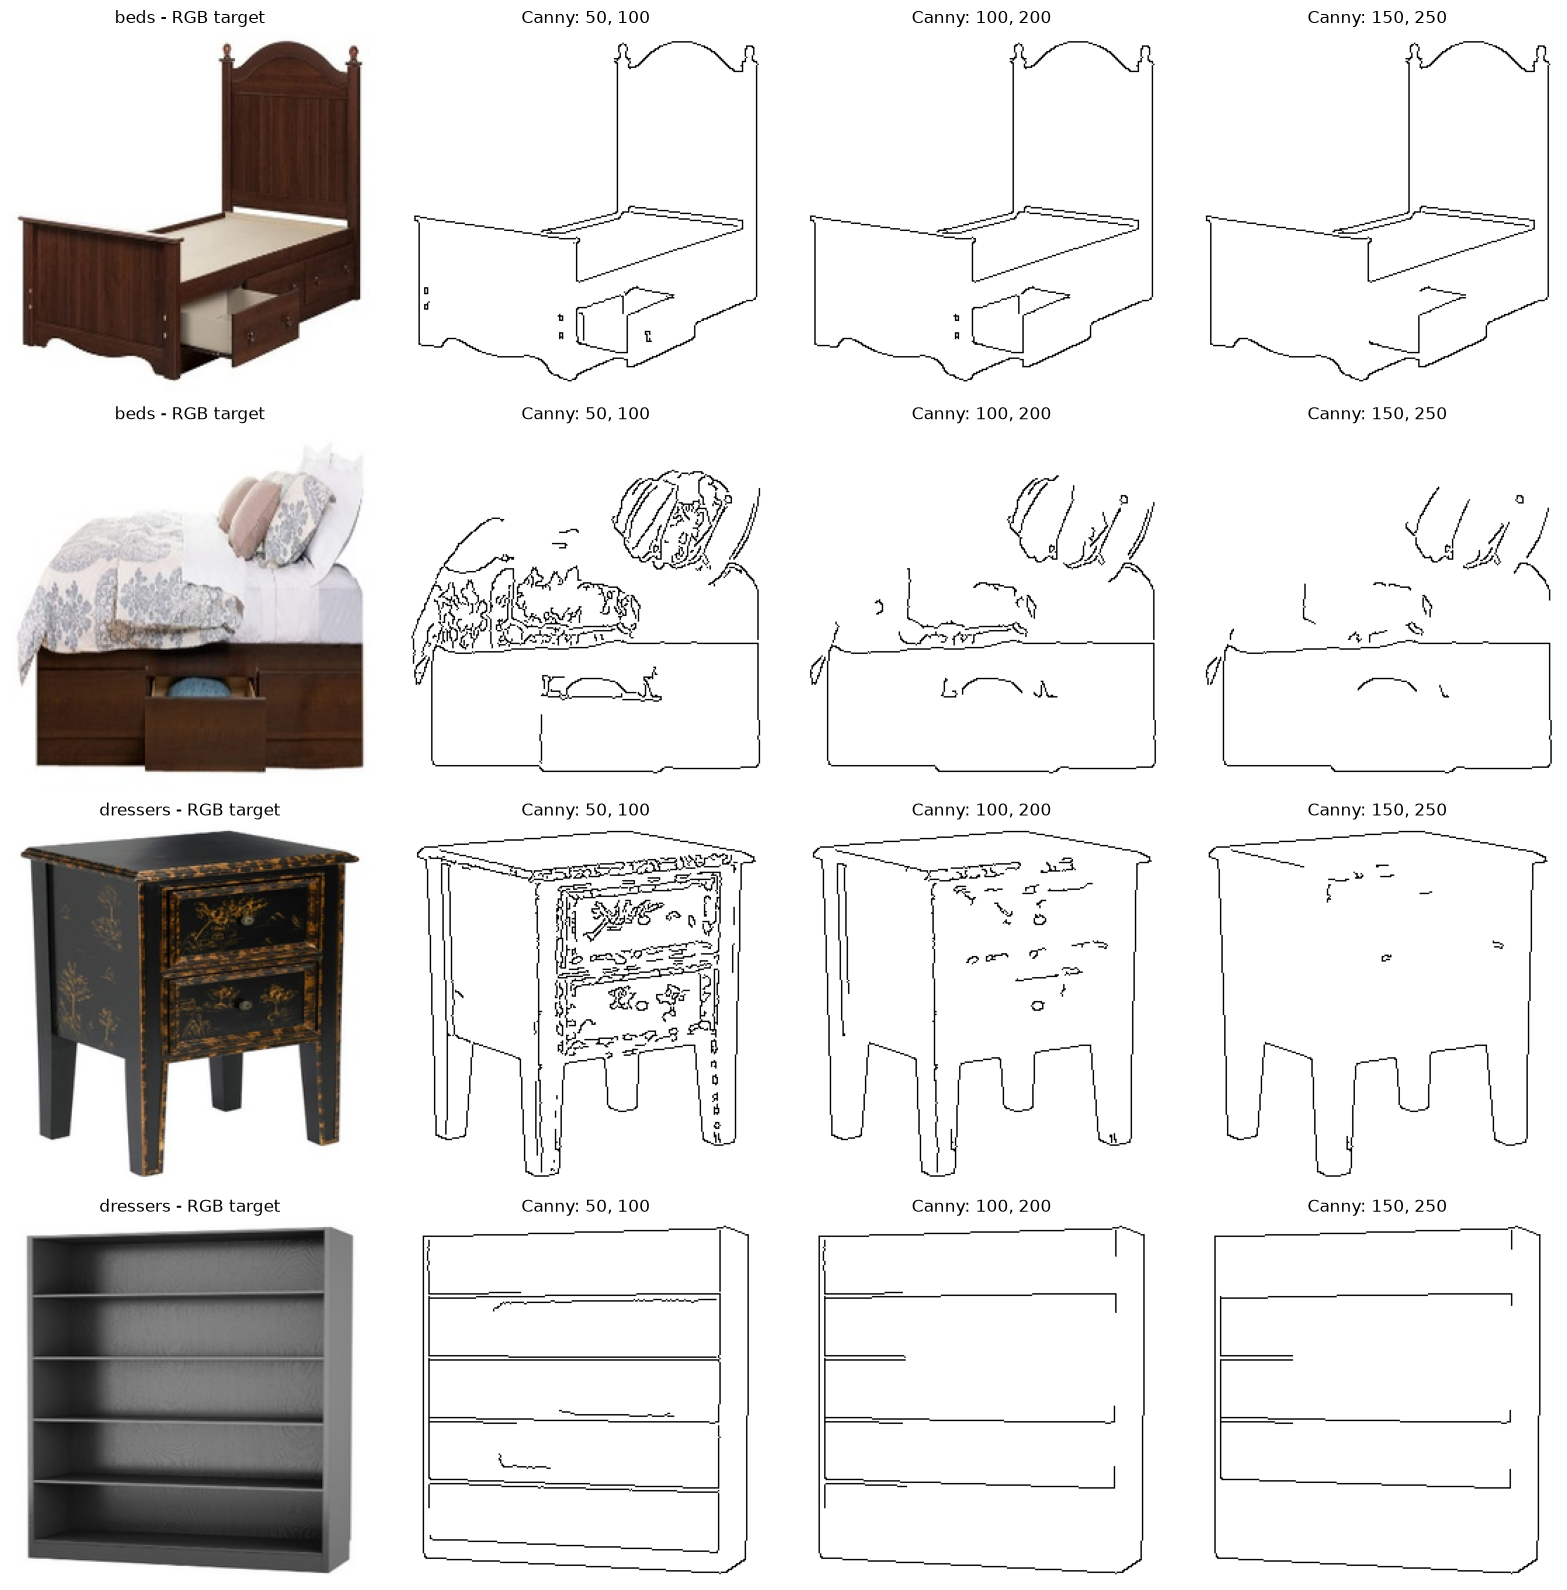

In [4]:
# Canny Threshold Comparison - comparing three sensible settings on two beds and two dressers

canny_threshold_options = {
    "50, 100": (50, 100),
    "100, 200": (100, 200),
    "150, 250": (150, 250),
}

threshold_sample = (
    preparation_metadata
    .groupby("category", group_keys=False,)
    .sample(n=2, random_state=42,)
    .sort_values(["category", "relative_path"])
    .reset_index(drop=True)
)

figure, axes = plt.subplots(
    nrows=len(threshold_sample),
    ncols=len(canny_threshold_options) + 1,
    figsize=(16, 4 * len(threshold_sample)),
)

for row_index, record in threshold_sample.iterrows():

    target_array = None

    for column_index, (threshold_label, thresholds) in enumerate(canny_threshold_options.items(), start=1):
        lower_threshold, upper_threshold = thresholds

        sketch_image, current_target = create_image_pair(record["source_path"], lower_threshold, upper_threshold)

        if target_array is None:
            target_array = current_target

        axes[row_index, column_index].imshow(sketch_image, cmap="gray", vmin=0, vmax=255)
        axes[row_index, column_index].set_title(f"Canny: {threshold_label}")


    axes[row_index, 0].imshow(target_array)
    axes[row_index, 0].set_title(f"{record['category']} - RGB target")


    for axis in axes[row_index]:
        axis.axis("off")


plt.tight_layout()
plt.show()



### Observation:

All three threshold combinations preserve the main furniture contours, but their treatment of internal detail differs. The 50 and 100 thresholds retain many texture and decorative edges, producing a cluttered input for the patterned bed and ornate dresser. The 150 and 250 thresholds create cleaner sketches but remove useful structural details from more complex objects. The 100 and 200 thresholds provide the most balanced result by preserving important outer and internal edges while reducing unnecessary texture noise.

In [5]:
# Selected Transformation Parameters

CANNY_LOWER_THRESHOLD = 100
CANNY_UPPER_THRESHOLD = 200

print(
    "Selected Canny thresholds: "
    f"{CANNY_LOWER_THRESHOLD}, "
    f"{CANNY_UPPER_THRESHOLD}"
)

Selected Canny thresholds: 100, 200


## Paired Dataset Structure

The prepared dataset is organized by the original train, validation, and test assignments. Each split contains an `A` directory for the black-on-white Canny inputs and a `B` directory for the corresponding RGB targets.

Matching input and target images use the same unique pair identifier and PNG filename. The identifiers are assigned after sorting the records by their original relative paths, making the naming reproducible for the unchanged cleaned metadata.

In [6]:
# Output Directory Configuration

PROCESSED_DATA_DIR = (PROJECT_ROOT / "data" / "processed")

PAIRED_DATA_DIR = (PROCESSED_DATA_DIR / "paired")

SPLIT_NAMES = ("train", "validation", "test")

INPUT_DIRECTORY_NAME = "A"
TARGET_DIRECTORY_NAME = "B"

for split_name in SPLIT_NAMES:
    input_directory = (PAIRED_DATA_DIR / split_name / INPUT_DIRECTORY_NAME)

    target_directory = (PAIRED_DATA_DIR / split_name / TARGET_DIRECTORY_NAME)

    input_directory.mkdir(parents=True, exist_ok=True)
    target_directory.mkdir(parents=True, exist_ok=True)

print(f"Paired dataset root: {PAIRED_DATA_DIR}")

for split_name in SPLIT_NAMES:
    print(f"{split_name}: {INPUT_DIRECTORY_NAME}/ and {TARGET_DIRECTORY_NAME} / created")



Paired dataset root: /home/vanya/projects/SoftUni-Studies/Sketch2Furniture-Generation/data/processed/paired
train: A/ and B / created
validation: A/ and B / created
test: A/ and B / created


In [7]:
# Pair Identifier Creation

preparation_metadata = (preparation_metadata.sort_values("relative_path").reset_index(drop=True))

preparation_metadata["pair_id"] = [f"pair_{pair_number:05d}" for pair_number in range(1, len(preparation_metadata) + 1)]

preparation_metadata["input_path"] = [
    (PAIRED_DATA_DIR / split_name / INPUT_DIRECTORY_NAME / f"{pair_id}.png")
    for split_name, pair_id in zip(preparation_metadata["split"], preparation_metadata["pair_id"])
]

preparation_metadata["target_path"] = [
    (PAIRED_DATA_DIR / split_name / TARGET_DIRECTORY_NAME / f"{pair_id}.png")
    for split_name, pair_id in zip(preparation_metadata["split"], preparation_metadata["pair_id"])
]

print(f"Prepared records: {len(preparation_metadata)}")
print(f"Unique pair IDs: {preparation_metadata['pair_id'].is_unique}")
print(f"Unique input paths: {preparation_metadata['input_path'].is_unique}")
print(f"Unique target paths: {preparation_metadata['target_path'].is_unique}")

display(preparation_metadata[
        [
            "pair_id",
            "category",
            "split",
            "relative_path",
            "input_path",
            "target_path",
        ]
    ].head()
)

Prepared records: 14334
Unique pair IDs: True
Unique input paths: True
Unique target paths: True


,pair_id,category,split,relative_path,input_path,target_path
0,pair_00001,beds,train,houzz/beds/Asian/19726asian-daybeds.jpg,/home/vanya/projects/SoftUni-Studies/Sketch2Fu...,/home/vanya/projects/SoftUni-Studies/Sketch2Fu...
1,pair_00002,beds,train,houzz/beds/Asian/20027asian-canopy-beds.jpg,/home/vanya/projects/SoftUni-Studies/Sketch2Fu...,/home/vanya/projects/SoftUni-Studies/Sketch2Fu...
2,pair_00003,beds,train,houzz/beds/Asian/20109asian-panel-beds.jpg,/home/vanya/projects/SoftUni-Studies/Sketch2Fu...,/home/vanya/projects/SoftUni-Studies/Sketch2Fu...
3,pair_00004,beds,train,houzz/beds/Asian/20508asian-platform-beds.jpg,/home/vanya/projects/SoftUni-Studies/Sketch2Fu...,/home/vanya/projects/SoftUni-Studies/Sketch2Fu...
4,pair_00005,beds,validation,houzz/beds/Asian/20750asian-comforters-and-com...,/home/vanya/projects/SoftUni-Studies/Sketch2Fu...,/home/vanya/projects/SoftUni-Studies/Sketch2Fu...


### Observation:

The paired dataset directories were created for all three splits. Each of the 14334 records received a unique pair identifier and unique input and target paths, ensuring a one-to-one correspondence between every Canny input and RGB target. At this stage, only the directory structure and planned filenames have been created.

## Pilot Pair Generation

Before generating the complete paired dataset, one record from each category in each split is processed as a pilot. This verifies the transformation, output paths, and PNG saving process on six representative pairs.

In [8]:
pilot_metadata = (
    preparation_metadata
    .groupby(["split", "category"], group_keys=False)
    .sample(n=1, random_state=42)
    .sort_values(["split", "category"])
    .reset_index(drop=True)
                  
)

for _, record in pilot_metadata.iterrows():
    sketch_image, target_image = create_image_pair(record["source_path"], CANNY_LOWER_THRESHOLD, CANNY_UPPER_THRESHOLD)

    Image.fromarray(sketch_image).save(record["input_path"])
    Image.fromarray(target_image).save(record["target_path"])


pilot_metadata["input_exists"] = (pilot_metadata["input_path"].map(Path.exists))

pilot_metadata["target_exists"] = (pilot_metadata["target_path"].map(Path.exists))

print(f"Pilot pairs generated: {len(pilot_metadata)}")

print(f"Pilot input files found: {pilot_metadata['input_exists'].sum()}")

print(f"Pilot target files found: {pilot_metadata['target_exists'].sum()}")

display(pilot_metadata[
    [
        "pair_id",
        "category",
        "split",
        "input_exists",
        "target_exists"
    ]
])


Pilot pairs generated: 6
Pilot input files found: 6
Pilot target files found: 6


,pair_id,category,split,input_exists,target_exists
0,pair_03462,beds,test,True,True
1,pair_10721,dressers,test,True,True
2,pair_05171,beds,train,True,True
3,pair_12538,dressers,train,True,True
4,pair_01282,beds,validation,True,True
5,pair_09419,dressers,validation,True,True


### Observation:

Six pilot pairs were generated successfully, covering one bed and one dresser from each dataset split. All input and target files were saved to their planned locations, confirming that the transformation and output-path workflow operates correctly.

In [9]:
# Pilot Image Property Validation

pilot_validation_records = []

for _, record in pilot_metadata.iterrows():
    with Image.open(record["input_path"]) as input_image:
        input_size = input_image.size
        input_mode = input_image.mode

    with Image.open(record["target_path"]) as target_image:
        target_size = target_image.size
        target_mode = target_image.mode

    pilot_validation_records.append(
        {
            "pair_id": record["pair_id"],
            "category": record["category"],
            "split": record["split"],
            "input_size": input_size,
            "input_mode": input_mode,
            "target_size": target_size,
            "target_mode": target_mode,
        }
    )


pilot_validation = pd.DataFrame(pilot_validation_records)

print(f"All input sizes valid: {pilot_validation['input_size'].map(lambda size: size == IMAGE_SIZE).all()}")

print(f"All target sizes valid: {pilot_validation['target_size'].map(lambda size: size == IMAGE_SIZE).all()}")

print(f"All input modes valid: {pilot_validation['input_mode'].eq('L').all()}")

print(f"All target modes valid: {pilot_validation['target_mode'].eq('RGB').all()}")

All input sizes valid: True
All target sizes valid: True
All input modes valid: True
All target modes valid: True


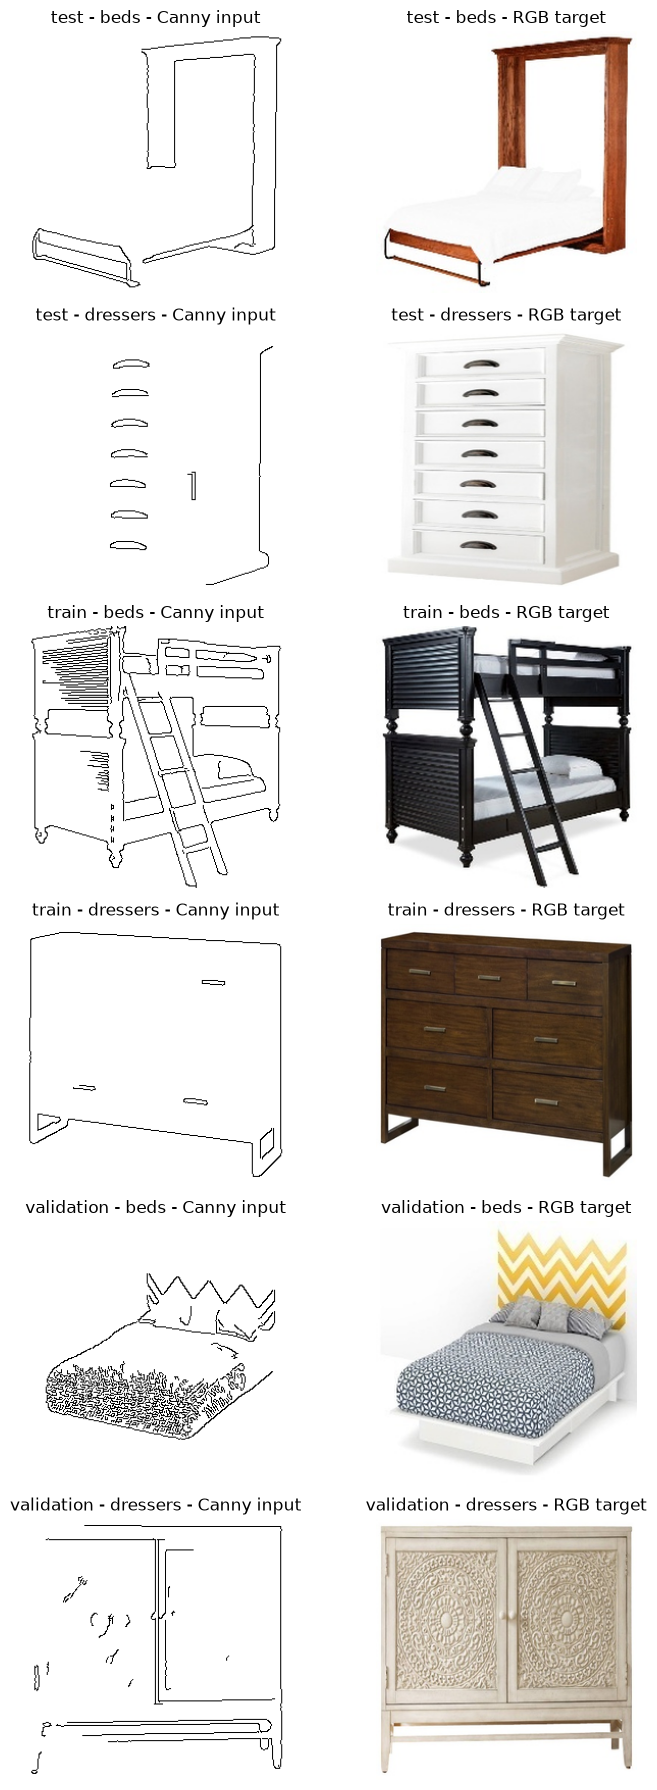

In [10]:
# Pilot Pair Visualization

figure, axes = plt.subplots(
    nrows=len(pilot_metadata),
    ncols=2,
    figsize=(8, 3 * len(pilot_metadata)),
)

for row_index, record in pilot_metadata.iterrows():
    with Image.open(record["input_path"]) as image:
        sketch_image = np.asarray(image)

    with Image.open(record["target_path"]) as image:
        target_image = np.asarray(image)

    axes[row_index, 0].imshow(sketch_image, cmap="grey", vmin=0, vmax=255,)
    axes[row_index, 0].set_title(f"{record['split']} - {record['category']} - Canny input")

    axes[row_index, 1].imshow(target_image)
    axes[row_index, 1].set_title(f"{record['split']} - {record['category']} - RGB target")

    for axis in axes[row_index]:
        axis.axis("off")

plt.tight_layout()
plt.show()

### Observation:

All six pilot pairs have the required 256 × 256 dimensions and image modes. The saved Canny inputs use black edges on white backgrounds, while the targets preserve their RGB information. Edge density varies with object contrast and surface detail: patterned furniture produces more internal edges, while white or minimally textured furniture produces simpler sketches. Nevertheless, the principal furniture structures remain identifiable, so the selected transformation is suitable for full dataset generation.

## Full Paired Dataset Generation

After validating the pilot pairs, the selected transformation is applied to all cleaned records. Existing pilot files are safely overwritten using the same pair identifiers and output paths. Any processing failures are recorded without interrupting the remaining generation process.

In [11]:
from tqdm.auto import tqdm

generation_success = []
generation_errors = []

for record in tqdm(preparation_metadata.itertuples(index=False), total=len(preparation_metadata), desc="Generating image pairs"):
    try:
        sketch_image, target_image = create_image_pair(record.source_path, CANNY_LOWER_THRESHOLD, CANNY_UPPER_THRESHOLD)

        Image.fromarray(sketch_image).save(record.input_path, format="PNG")
        Image.fromarray(target_image).save(record.target_path, format="PNG")


        generation_success.append(True)
        generation_errors.append(None)

    except Exception as error:
        generation_success.append(False)
        generation_errors.append(str(error))


preparation_metadata["generation_success"] = generation_success
preparation_metadata["generation_error"] = generation_errors

generation_summary = (preparation_metadata
    .groupby("split")
    .agg(planned_pairs=("pair_id", "size"), generated_pairs=("generation_success", "sum"))
    .reindex(SPLIT_NAMES)
    .reset_index()
)

generation_summary["failed_pairs"] = (generation_summary["planned_pairs"] - generation_summary["generated_pairs"])

print(f"Total pairs generated: {preparation_metadata['generation_success'].sum()}")
print(f"Total failed pairs: {(~preparation_metadata['generation_success']).sum()}")

display(generation_summary)


Generating image pairs:   0%|          | 0/14334 [00:00<?, ?it/s]

Total pairs generated: 14334
Total failed pairs: 0


,split,planned_pairs,generated_pairs,failed_pairs
0,train,9729,9729,0
1,validation,1713,1713,0
2,test,2892,2892,0


### Observation:

The complete paired dataset was generated successfully. All 14334 cleaned records produced an input sketch and corresponding RGB target, with no processing failures. The generated counts match the planned counts for the train, validation, and test splits.

## Prepared Dataset Validation

The generated dataset is validated to confirm that every expected input and target exists, the original split assignments are preserved, and all images have the required properties. The edge maps are also examined for unusually sparse or dense results.

In [12]:
# Pair and Split Validation

pair_validation_records = []

for split_name in SPLIT_NAMES:
    split_metadata = preparation_metadata[preparation_metadata["split"].eq(split_name)]

    input_directory = PAIRED_DATA_DIR / split_name / INPUT_DIRECTORY_NAME
    target_directory = PAIRED_DATA_DIR / split_name / TARGET_DIRECTORY_NAME

    expected_filenames = {f"{pair_id}.png" for pair_id in split_metadata["pair_id"]}

    input_filenames = {path.name for path in input_directory.glob("*.png")}
    target_filenames = {path.name for path in target_directory.glob("*.png")}

    pair_validation_records.append(
        {
            "split":split_name,
            "expected_pairs": len(expected_filenames),
            "input_files": len(input_filenames),
            "target_files": len(target_filenames),
            "input_names_valid": (input_filenames == expected_filenames),
            "target_names_valid": (target_filenames == expected_filenames),
            "paired_names_valid": (input_filenames == target_filenames),    
        }
    )

pair_split_validation = pd.DataFrame(pair_validation_records)

counts_valid = (
    pair_split_validation["input_files"].eq(
        pair_split_validation["expected_pairs"]
    )
    & pair_split_validation["target_files"].eq(
        pair_split_validation["expected_pairs"]
    )
).all()

print(f"All split counts valid: {counts_valid}")

print(f"All input filenames valid: {pair_split_validation['input_names_valid'].all()}")

print(f"All target filenames valid: {pair_split_validation['target_names_valid'].all()}")

print(f"All input-target names paired: {pair_split_validation['paired_names_valid'].all()}")

display(pair_split_validation)

All split counts valid: True
All input filenames valid: True
All target filenames valid: True
All input-target names paired: True


,split,expected_pairs,input_files,target_files,input_names_valid,target_names_valid,paired_names_valid
0,train,9729,9729,9729,True,True,True
1,validation,1713,1713,1713,True,True,True
2,test,2892,2892,2892,True,True,True


### Observation:

Pair and split validation confirmed that every expected input and target file is present. The generated counts exactly match the original train, validation, and test assignments, and matching filenames preserve a one-to-one correspondence between all input sketches and RGB targets. No missing, unpaired, or unexpected PNG files were detected.

In [13]:
# Image Property and Edge-Map Validation

validation_records = []

for record in tqdm(
    preparation_metadata.itertuples(index=False),
    total=len(preparation_metadata),
    desc="Validating prepared pairs",
):
    with (
        Image.open(record.input_path) as input_image,
        Image.open(record.target_path) as target_image,
    ):
        input_image.load()
        target_image.load()

        validation_records.append(
            {
                "split": record.split,
                "pair_id": record.pair_id,
                "input_valid": (input_image.size == IMAGE_SIZE and input_image.mode == "L" and input_image.format == "PNG"),
                "target_valid": (target_image.size == IMAGE_SIZE and target_image.mode == "RGB" and target_image.format == "PNG"),
                "edge_density": (np.asarray(input_image) == 0).mean() * 100,
            }
        )

prepared_validation = pd.DataFrame(validation_records)

all_images_valid = (
    len(prepared_validation) == len(preparation_metadata) 
    and prepared_validation[["input_valid", "target_valid"]].all().all()
    and prepared_validation["edge_density"].between(0, 100, inclusive="neither").all()
)

validation_summary = (
    prepared_validation
    .groupby("split")
    .agg(
        pairs=("pair_id", "size"),
        inputs_valid=("input_valid", "all"),
        targets_valid=("target_valid", "all"),
        minimum_density=("edge_density", "min"),
        mean_density=("edge_density", "mean"),
        maximum_density=("edge_density", "max"),
    )
    .reindex(SPLIT_NAMES)
    .round(2)
)

print(f"All prepared images valid: {all_images_valid}")
display(validation_summary)

Validating prepared pairs:   0%|          | 0/14334 [00:00<?, ?it/s]

All prepared images valid: False


,pairs,inputs_valid,targets_valid,minimum_density,mean_density,maximum_density
split,,,,,,
train,9729,True,True,0.00,4.02,20.75
validation,1713,True,True,0.00,3.99,23.41
test,2892,True,True,0.05,4.08,23.22


The overall validation result is examined to identify the records responsible for the failed check. This includes images with incorrect properties and edge maps that are completely blank or completely black.

In [15]:
# Finding Failed Validation Records

failed_validation = prepared_validation[
    ~prepared_validation["input_valid"]
    | ~prepared_validation["target_valid"]
    | ~prepared_validation["edge_density"].between(
        0,
        100,
        inclusive="neither",
    )
]

print(f"Failed records: {len(failed_validation)}")
display(failed_validation)

Failed records: 16


,split,pair_id,input_valid,target_valid,edge_density
979,train,pair_00980,True,True,0.0
1293,train,pair_01294,True,True,0.0
1447,validation,pair_01448,True,True,0.0
1691,train,pair_01692,True,True,0.0
2662,train,pair_02663,True,True,0.0
3612,train,pair_03613,True,True,0.0
3967,train,pair_03968,True,True,0.0
4925,train,pair_04926,True,True,0.0
5989,train,pair_05990,True,True,0.0
7372,validation,pair_07373,True,True,0.0


### Observation:

The validation identified 16 failed records. Their input and target properties are valid, but each input has 0% edge density, meaning that Canny produced a completely blank edge map. These records are inspected visually before making a cleaning decision.

### Blank Edge-Map Inspection

The targets corresponding to the blank edge maps are displayed to determine whether they originate from empty, unsuitable, or extremely low-contrast source images.

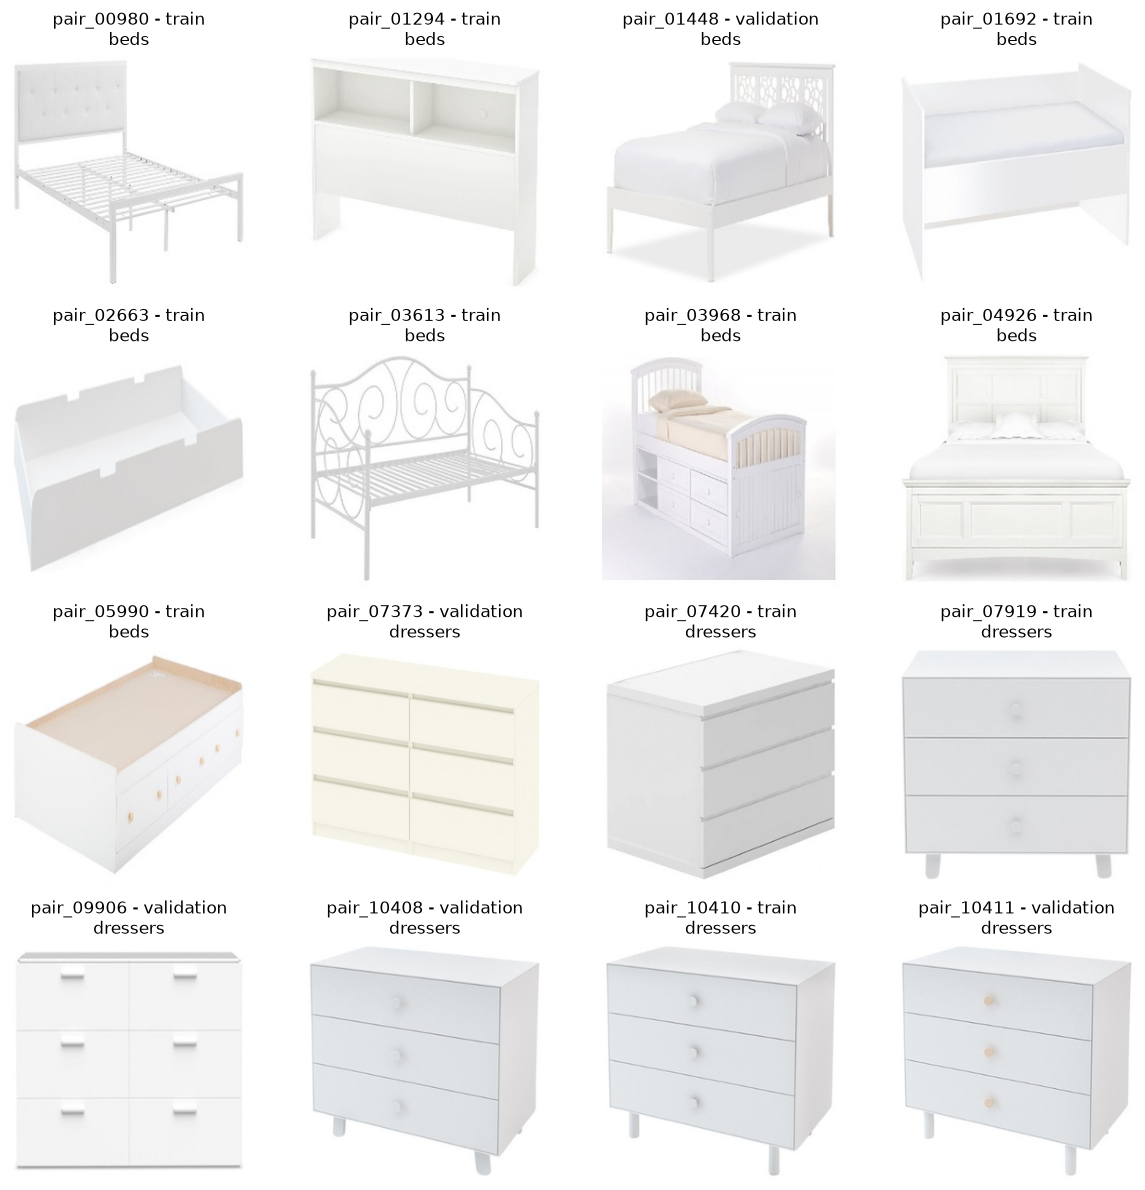

In [16]:

blank_pairs = preparation_metadata[
    preparation_metadata["pair_id"].isin(failed_validation["pair_id"])
].sort_values("pair_id")

figure, axes = plt.subplots(4, 4, figsize=(12, 12),)

for axis, record in zip(axes.flat, blank_pairs.itertuples(index=False)):
    with Image.open(record.target_path) as image:
        axis.imshow(image)

    axis.set_title(
        f"{record.pair_id} - {record.split}\n"
        f"{record.category}"
    )
    axis.axis("off")

plt.tight_layout()
plt.show()

### Observation:

All 16 blank edge maps correspond to white or very light furniture photographed against white backgrounds. The limited intensity contrast prevents the selected Canny thresholds from detecting meaningful edges. Since these records represent only 0.11% of the prepared dataset and other white furniture images retain usable edge information, only the completely blank pairs are excluded. The selected Canny thresholds remain unchanged.

In [17]:
# Excluding Blank Edge Maps

blank_pair_ids = set(failed_validation["pair_id"])

final_metadata = (
    preparation_metadata[~preparation_metadata["pair_id"].isin(blank_pair_ids)]
    .copy()
    .reset_index(drop=True)
)

print(f"Excluded blank pairs: {len(blank_pair_ids)}")
print(f"Final pairs: {len(final_metadata)}")

display(
    final_metadata
    .groupby("split")
    .size()
    .reindex(SPLIT_NAMES)
    .to_frame("pairs")
)

Excluded blank pairs: 16
Final pairs: 14318


,pairs
split,
train,9718
validation,1708
test,2892


### Observation:

The 16 completely blank pairs were excluded from the final metadata, leaving 14318 usable pairs: 9718 training, 1708 validation, and 2892 test pairs. White furniture examples with detectable edges remain included; only inputs containing no structural information were excluded.

## Final Pair Visualization

A final sample of prepared pairs is displayed from each split to confirm the visual correspondence between the Canny inputs and RGB targets after excluding blank edge maps.

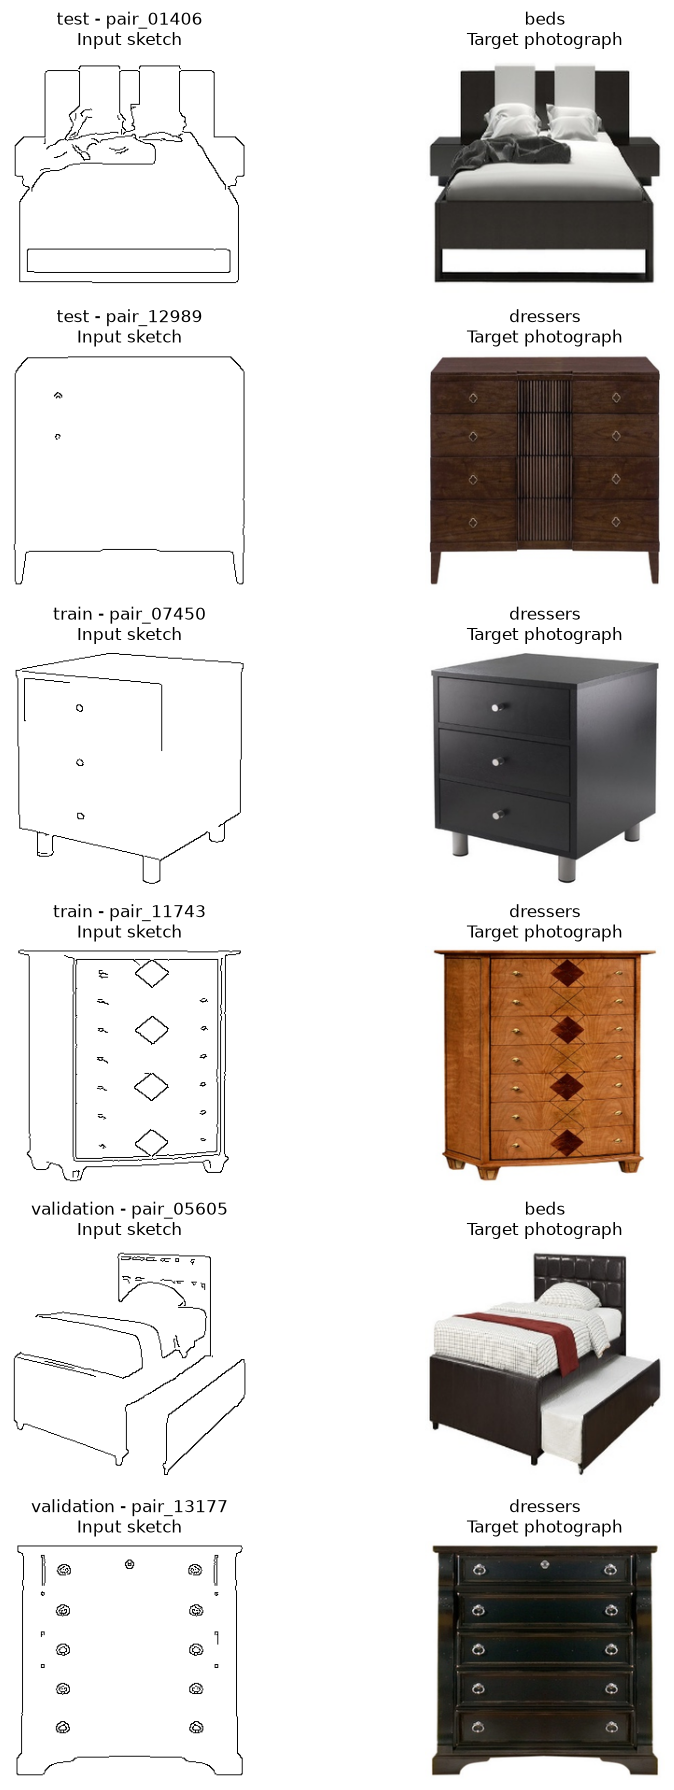

In [18]:

final_samples = (final_metadata
    .groupby("split", group_keys=False)
    .sample(n=2, random_state=42)
    .sort_values(["split", "pair_id"])
)

figure, axes = plt.subplots(len(final_samples), 2, figsize=(10, 3 * len(final_samples)),)

for row, record in enumerate(final_samples.itertuples(index=False)):
    with Image.open(record.input_path) as input_image:
        axes[row, 0].imshow(input_image, cmap="gray")

    with Image.open(record.target_path) as target_image:
        axes[row, 1].imshow(target_image)

    axes[row, 0].set_title(f"{record.split} - {record.pair_id}\nInput sketch")
    axes[row, 1].set_title(f"{record.category}\nTarget photograph")

    axes[row, 0].axis("off")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

### Observation:

Manual inspection confirmed that the sampled input sketches correspond to the correct target photographs across all splits. The main furniture shapes and components are generally recognizable, although some edge maps contain sparse or disconnected contours and omit parts of the object boundaries. These incomplete inputs may require the generator to infer missing details and could reduce reconstruction accuracy. No blank or mismatched pairs were observed in the final sample.

## Saving the Prepared Dataset Metadata

The final metadata is saved as the authoritative manifest for model training. It contains only usable input-target pairs, allowing the excluded blank files to remain on disk for traceability without being loaded during training.

In [19]:

PREPARED_METADATA_PATH = (PAIRED_DATA_DIR / "prepared_metadata.csv")

final_metadata.to_csv(PREPARED_METADATA_PATH, index=False)

saved_metadata = pd.read_csv(PREPARED_METADATA_PATH)

metadata_saved_correctly = (
    len(saved_metadata) == len(final_metadata)
    and saved_metadata["pair_id"].is_unique
    and saved_metadata["pair_id"].astype(str).tolist()
    == final_metadata["pair_id"].astype(str).tolist()
)

print(f"Metadata saved correctly: {metadata_saved_correctly}")

display(saved_metadata
    .groupby("split")
    .size()
    .reindex(SPLIT_NAMES)
    .to_frame("pairs")
)

Metadata saved correctly: True


,pairs
split,
train,9718
validation,1708
test,2892


### Observation:

The prepared metadata was saved and reloaded successfully. It contains 14318 unique usable pairs: 9718 training, 1708 validation, and 2892 test pairs. This manifest will control which files are loaded during model training, ensuring that the 16 blank edge maps are excluded.

## Conclusions and Next Steps

This notebook transformed the cleaned furniture photographs into paired data for conditional image generation. Each pair contains a 256 × 256 grayscale Canny edge map and its corresponding 256 × 256 RGB target photograph. Matching identifiers preserve the one-to-one correspondence between the files and the original dataset splits.

All 14334 selected records were processed successfully. Validation confirmed the expected file counts, names, dimensions, modes, formats, and pair correspondence. Sixteen completely blank edge maps were identified and excluded from the final metadata, leaving 14318 usable pairs. Manual inspection confirmed that the remaining sampled sketches correspond to the correct targets.

Some edge maps contain sparse or disconnected contours and do not explicitly encode colour, material, or texture. The generator must therefore infer missing structural and appearance information, which may produce generic or inaccurate details.

The next notebook will use the saved metadata to create a PyTorch dataset and data loaders, normalize the images to `[-1, 1]`, and implement a reconstruction-only U-Net baseline trained with $L_1$ loss. This baseline will test how well the network can reconstruct target photographs from the edge maps without adversarial training. Notebook 04 will then implement the full Pix2Pix model by combining the U-Net generator with a PatchGAN discriminator and adversarial and $L_1$ losses, allowing the two approaches to be compared.